In [3]:
import lightkurve as lk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

print("All imports working!")
print("lightkurve version:", lk.__version__)

C:\Users\princ\anaconda3\envs\apna_college\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


All imports working!
lightkurve version: 2.6.0


In [5]:
# Pi Mensae — a bright, well-known star with a confirmed transiting planet (Pi Men c)
# It's in TESS Sector 1, one of the first planets TESS ever found.
search = lk.search_lightcurve('Pi Mensae', mission='TESS', sector=1)
print(search)

SearchResult containing 8 data products.

 #     mission     year       author      exptime target_name distance
                                             s                 arcsec 
--- -------------- ---- ----------------- ------- ----------- --------
  0 TESS Sector 01 2018              SPOC     120   261136679      0.0
  1 TESS Sector 01 2018         TESS-SPOC    1800   261136679      0.0
  2 TESS Sector 01 2018               QLP    1800   261136679      0.0
  3 TESS Sector 01 2018 GSFC-ELEANOR-LITE    1800   261136679      0.0
  4 TESS Sector 01 2018              TARS    1800   261136679      0.0
  5 TESS Sector 01 2018             TASOC     120   261136679      0.0
  6 TESS Sector 01 2018             TASOC    1800   261136679      0.0
  7 TESS Sector 01 2018             TASOC    1800   261136679      0.0


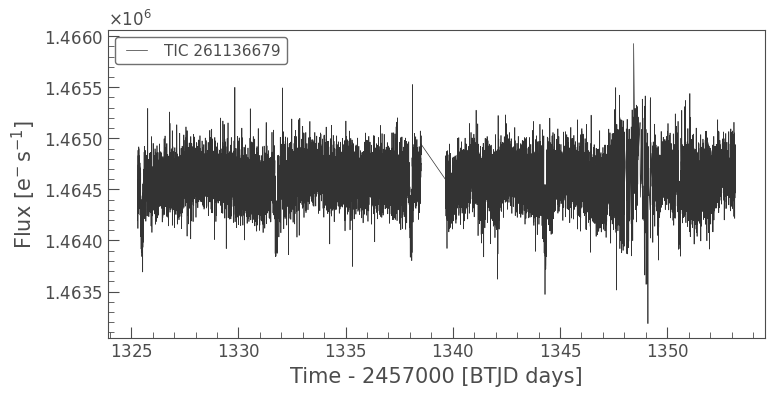

In [6]:
# Grab row 0 — the SPOC, 2-minute cadence light curve
lc = search[0].download()

# Plot it
lc.plot()
plt.show()

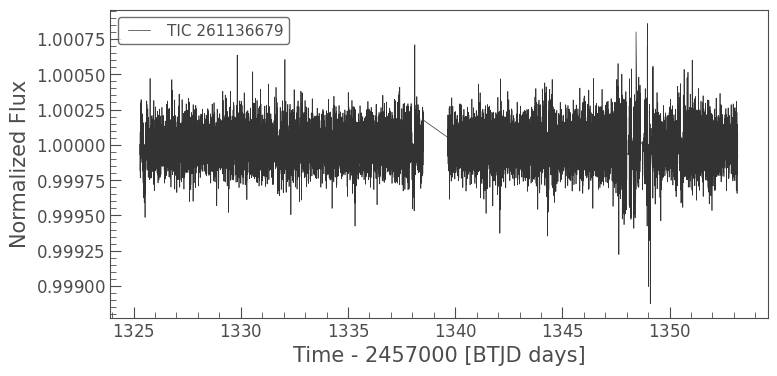

In [7]:
# Remove long-term drift/wobble, keep short transit dips
lc_clean = lc.remove_nans().flatten(window_length=401)

lc_clean.plot()
plt.show()

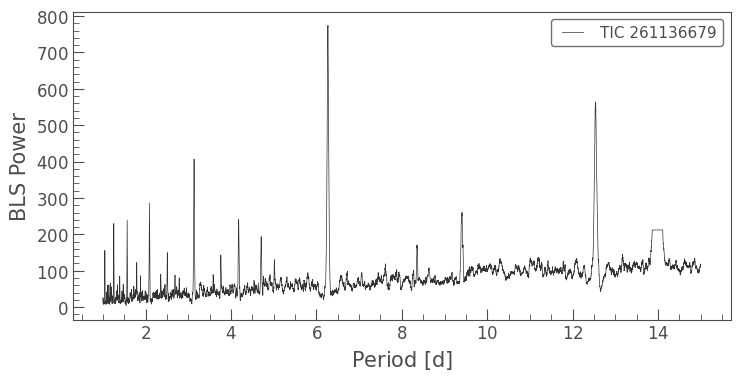

Best period found: 6.27012701270127 d


In [8]:
# Search a range of possible periods (in days)
periodogram = lc_clean.to_periodogram(method='bls',
                                       period=np.linspace(1, 15, 10000))

# Plot the BLS power across all periods
periodogram.plot()
plt.show()

# The period with the strongest signal:
best_period = periodogram.period_at_max_power
print("Best period found:", best_period)

Period: 6.27012701270127 d
Transit time (t0): 1325.4969604950604


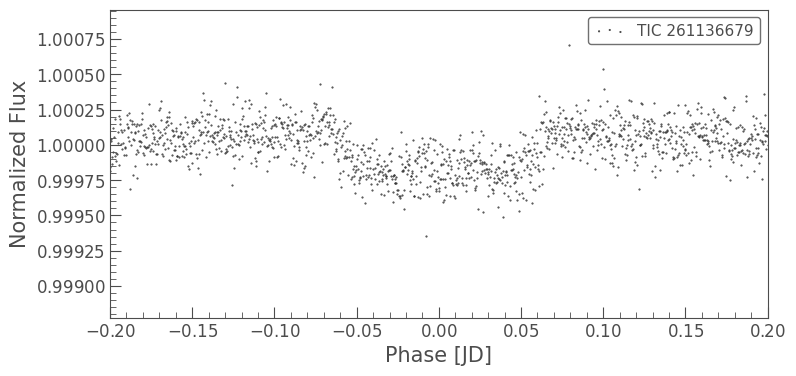

In [9]:
# Pull the key numbers BLS found
best_period = periodogram.period_at_max_power
best_t0     = periodogram.transit_time_at_max_power   # when a transit happens

print("Period:", best_period)
print("Transit time (t0):", best_t0)

# Fold the light curve at the detected period
folded = lc_clean.fold(period=best_period, epoch_time=best_t0)

# Plot folded — zoom in around the transit
folded.scatter(s=1)
plt.xlim(-0.2, 0.2)   # zoom to the dip near phase 0
plt.show()

In [10]:
# BLS gives us these directly at the best period
stats = periodogram

best_period   = stats.period_at_max_power
best_t0       = stats.transit_time_at_max_power
best_duration = stats.duration_at_max_power
best_depth    = stats.depth_at_max_power
best_power    = stats.max_power   # related to detection significance / SNR

print("Orbital Period :", best_period)
print("Transit Duration:", best_duration)
print("Transit Depth  :", best_depth)
print("BLS Power (SNR proxy):", best_power)

Orbital Period : 6.27012701270127 d
Transit Duration: 0.1 d
Transit Depth  : 0.00018624301004223945
BLS Power (SNR proxy): 773.9702551821574


In [11]:
# A simple, defensible SNR: depth divided by the noise scatter
noise = np.std(lc_clean.flux)          # scatter of the flattened light curve
snr = best_depth / noise

print("Estimated noise (scatter):", noise)
print("Transit SNR:", snr)

Estimated noise (scatter): 0.00012656904062017084
Transit SNR: 1.4714736647261792


In [12]:
# How many data points fall inside transits
# (duration / period) = fraction of orbit in transit; times total points, times number of orbits observed
n_total = len(lc_clean.flux)
transit_fraction = (best_duration / best_period).value
n_in_transit = int(n_total * transit_fraction)

# Per-point noise
noise = np.std(lc_clean.flux)

# SNR improves by sqrt(number of in-transit points)
snr = (best_depth / noise) * np.sqrt(n_in_transit)

print("Total points:", n_total)
print("Points in transit:", n_in_transit)
print("Proper transit SNR:", snr)

Total points: 18264
Points in transit: 291
Proper transit SNR: 25.10146033761708


In [13]:
# start from here 


# import lightkurve as lk
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier


In [14]:
def analyze_star(target, sector=1, period_range=(1, 15)):
    """
    Full detection pipeline for ONE star.
    Input : target (star name or TIC ID), sector, period search range
    Output: a dictionary of results (or None if no usable data)
    """
    try:
        # 1. FETCH — get the SPOC 2-min light curve
        search = lk.search_lightcurve(target, mission='TESS',
                                      sector=sector, author='SPOC', exptime=120)
        if len(search) == 0:
            return None                      # no data for this star
        lc = search[0].download()

        # 2. CLEAN — remove gaps and slow drift
        lc_clean = lc.remove_nans().flatten(window_length=401)

        # 3. DETECT — run BLS across candidate periods
        pg = lc_clean.to_periodogram(method='bls',
                                     period=np.linspace(period_range[0],
                                                        period_range[1], 5000))

        # 4. EXTRACT — pull the best-fit parameters
        period   = pg.period_at_max_power
        t0       = pg.transit_time_at_max_power
        duration = pg.duration_at_max_power
        depth    = pg.depth_at_max_power
        power    = pg.max_power

        # 5. SNR — significance accounting for in-transit points
        noise = np.std(lc_clean.flux)
        n_total = len(lc_clean.flux)
        n_in_transit = max(int(n_total * (duration / period).value), 1)
        snr = (depth / noise) * np.sqrt(n_in_transit)

        # 6. RETURN — everything bundled neatly
        return {
            "target":   str(target),
            "period":   float(period.value),
            "t0":       float(t0.value),
            "duration": float(duration.value),
            "depth":    float(depth),
            "bls_power": float(power),
            "snr":      float(snr),
        }

    except Exception as e:
        # If anything fails (bad data, download error), skip gracefully
        print(f"Failed on {target}: {e}")
        return None

In [15]:
result = analyze_star('Pi Mensae', sector=1)
print(result)

{'target': 'Pi Mensae', 'period': 6.270654130826166, 't0': 1325.4969604950604, 'duration': 0.1, 'depth': 0.00018657990526576716, 'bls_power': 776.7738394070883, 'snr': 25.146866401927337}


In [16]:
#import pandas as pd

# A small test batch of Sector 1 targets
test_targets = [
    'Pi Mensae',      # known planet host (our validated case)
    'TIC 38846515',   # WASP-100, known hot Jupiter in Sector 1
    'TIC 25155310',   # WASP-18, very strong known transit
    'TIC 100100827',  # LHS 3844, known planet
]

# Run the pipeline on each, collect results
results = []
for t in test_targets:
    print(f"Analyzing {t} ...")
    r = analyze_star(t, sector=1)
    if r is not None:
        results.append(r)

# Build a results table
df = pd.DataFrame(results)
df

Analyzing Pi Mensae ...
Analyzing TIC 38846515 ...
Analyzing TIC 25155310 ...
Analyzing TIC 100100827 ...


,target,period,t0,duration,depth,bls_power,snr
0,Pi Mensae,6.270654,1325.496960,0.10,0.000187,776.773839,25.146866
1,TIC 38846515,2.848370,1329.600330,0.15,0.002762,2320.689480,59.539578
2,TIC 25155310,3.288058,1327.516626,0.15,0.002278,1190.543486,46.329520


In [17]:
# Check what's actually available for the missing star
check = lk.search_lightcurve('TIC 100100827', mission='TESS', sector=1)
print(check)

SearchResult containing 0 data products.


In [19]:
# Adjust the path/filename to match your downloaded file
toi = pd.read_csv('tois.csv')   # <-- change filename if different

print("Shape:", toi.shape)
print("\nColumns:")
print(toi.columns.tolist())
print("\nFirst few rows:")
toi.head()

Shape: (8064, 62)

Columns:
['TIC ID', 'Imaging Observations', 'Spectroscopy Observations', 'Time Series Observations', 'TOI', 'Previous CTOI', 'Master', 'SG1A', 'SG1B', 'SG2', 'SG3', 'SG4', 'SG5', 'ESM', 'TSM', 'Predicted Mass (M_Earth)', 'Predicted Radial Velocity Semi-amplitude (m/s)', 'TESS Mag', 'TESS Mag err', 'Planet Num', 'TESS Disposition', 'TFOPWG Disposition', 'Source', 'Detection', 'RA', 'Dec', 'PM RA (mas/yr)', 'PM RA err (mas/yr)', 'PM Dec (mas/yr)', 'PM Dec err (mas/yr)', 'Epoch (BJD)', 'Epoch (BJD) err', 'Period (days)', 'Period (days) err', 'Duration (hours)', 'Duration (hours) err', 'Depth (mmag)', 'Depth (mmag) err', 'Depth (ppm)', 'Depth (ppm) err', 'Planet Radius (R_Earth)', 'Planet Radius (R_Earth) err', 'Planet Insolation (Earth Flux)', 'Planet Equil Temp (K)', 'Planet SNR', 'Stellar Distance (pc)', 'Stellar Distance (pc) err', 'Stellar Eff Temp (K)', 'Stellar Eff Temp (K) err', 'Stellar log(g) (cm/s^2)', 'Stellar log(g) (cm/s^2) err', 'Stellar Radius (R_Sun)', '

,TIC ID,Imaging Observations,Spectroscopy Observations,Time Series Observations,TOI,Previous CTOI,Master,SG1A,SG1B,SG2,...,Stellar Radius (R_Sun) err,Stellar Metallicity,Stellar Metallicity err,Stellar Mass (M_Sun),Stellar Mass (M_Sun) err,Sectors,Comments,Date TOI Alerted (UTC),Date TOI Updated (UTC),Date Modified
0,231663901,3,1,0,101.01,NaN,5,5,5,5,...,0.043847,NaN,NaN,1.05,0.129454,"1,27,67",WASP-46 b,2018-09-05,2024-09-06,2025-07-31
1,149603524,1,2,1,102.01,NaN,5,5,5,5,...,0.050000,0.24,0.05,1.28,0.190812,"1,2,3,4,6,7,8,9,10,11,12,13,27,28,29,30,31,32,...",WASP-62 b,2019-05-07,2026-04-17,2026-06-03
2,336732616,9,0,0,103.01,NaN,5,5,5,5,...,NaN,NaN,NaN,1.27,0.196969,1,HATS-3 b,2018-09-05,2024-09-06,2025-07-31
3,231670397,3,0,1,104.01,NaN,5,5,5,5,...,0.102573,NaN,NaN,1.16,0.166129,"1,27,67",WASP-73 b,2018-09-05,2023-10-16,2025-07-31
4,144065872,2,3,1,105.01,NaN,5,5,5,5,...,0.059699,NaN,NaN,1.03,0.127209,"1,28,95",WASP-95 b,2018-09-05,2026-04-08,2026-06-03


In [20]:
print(toi['TFOPWG Disposition'].value_counts(dropna=False))

TFOPWG Disposition
PC     4879
FP     1244
CP      735
KP      592
APC     482
FA      100
NaN      32
Name: count, dtype: int64


In [21]:
# 1. Keep only the firmly-labeled rows
keep = ['CP', 'KP', 'FP', 'FA']
df = toi[toi['TFOPWG Disposition'].isin(keep)].copy()

# 2. Create the binary label: 1 = real planet, 0 = false positive
df['label'] = df['TFOPWG Disposition'].map({
    'CP': 1, 'KP': 1,    # real planets
    'FP': 0, 'FA': 0     # false positives
})

# 3. Pick the feature columns (what the model learns from)
features = ['Period (days)', 'Duration (hours)', 'Depth (ppm)',
            'Planet SNR', 'Planet Radius (R_Earth)',
            'Stellar Eff Temp (K)', 'Stellar Radius (R_Sun)']

# 4. Build the clean training table, drop rows with missing values
data = df[features + ['label']].dropna()

print("Training table shape:", data.shape)
print("\nClass balance:")
print(data['label'].value_counts())
print("\nPreview:")
data.head()

Training table shape: (2496, 8)

Class balance:
label
1    1302
0    1194
Name: count, dtype: int64

Preview:


,Period (days),Duration (hours),Depth (ppm),Planet SNR,Planet Radius (R_Earth),Stellar Eff Temp (K),Stellar Radius (R_Sun),label
0,1.430370,1.616599,18960.712294,151.721730,13.187450,5600.0,0.890774,1
1,4.411937,3.632128,14711.881030,3217.173463,15.064874,6280.0,1.210000,1
2,3.547854,3.494333,10424.371800,59.500000,14.581841,6351.0,1.400000,1
3,4.087296,5.586113,3572.171250,48.678577,13.623773,6036.0,2.218670,1
4,2.184667,2.698910,11535.547516,213.410961,13.712705,5630.0,1.238240,1


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Separate features (X) from the label (y)
X = data[features]
y = data['label']

# 2. Split: 80% train, 20% test (stratify keeps class balance in both)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training on:", X_train.shape[0], "stars")
print("Testing on :", X_test.shape[0], "stars")

# 3. Build and train the Random Forest
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# 4. Test it on the held-out data
y_pred = model.predict(X_test)

# 5. Report how well it did
print("\n--- Results ---")
print(classification_report(y_test, y_pred,
                            target_names=['False Positive', 'Real Planet']))

Training on: 1996 stars
Testing on : 500 stars

--- Results ---
                precision    recall  f1-score   support

False Positive       0.86      0.80      0.83       239
   Real Planet       0.83      0.88      0.85       261

      accuracy                           0.84       500
     macro avg       0.84      0.84      0.84       500
  weighted avg       0.84      0.84      0.84       500



What the model relies on most:
Period (days)              0.169749
Planet Radius (R_Earth)    0.168210
Stellar Radius (R_Sun)     0.162810
Depth (ppm)                0.130660
Stellar Eff Temp (K)       0.129026
Duration (hours)           0.122533
Planet SNR                 0.117013
dtype: float64


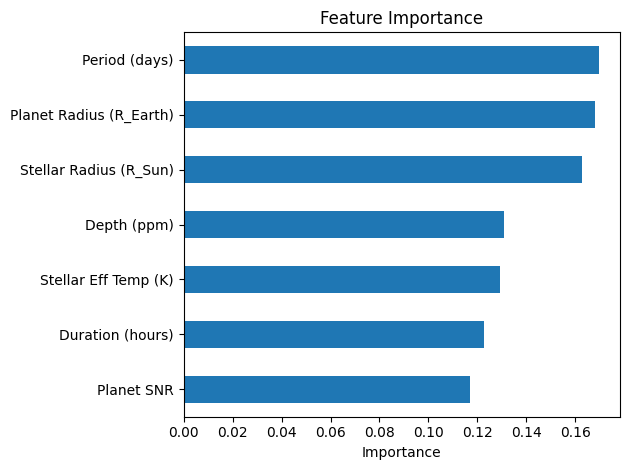

In [23]:
importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

print("What the model relies on most:")
print(importances)

importances.plot(kind='barh')
import matplotlib.pyplot as plt
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
probabilities = model.predict_proba(X_test)

for i in range(10):
    planet_conf = probabilities[i][1] * 100
    actual = "Planet" if y_test.iloc[i]==1 else "False Pos"
    print(f"Star {i}: {planet_conf:5.1f}% confident planet  (actually: {actual})")

Star 0:   1.0% confident planet  (actually: False Pos)
Star 1:  87.5% confident planet  (actually: Planet)
Star 2:  95.0% confident planet  (actually: Planet)
Star 3:  75.5% confident planet  (actually: Planet)
Star 4:  89.0% confident planet  (actually: Planet)
Star 5:  63.5% confident planet  (actually: False Pos)
Star 6:  39.5% confident planet  (actually: False Pos)
Star 7:  11.0% confident planet  (actually: False Pos)
Star 8:  16.5% confident planet  (actually: False Pos)
Star 9:   2.5% confident planet  (actually: False Pos)


In [25]:
import joblib

# Save the trained model + the feature list it expects
joblib.dump({'model': model, 'features': features},
            'exoplanet_classifier.pkl')

print("Model saved to exoplanet_classifier.pkl")

# (To reload later in any notebook:)
# saved = joblib.load('exoplanet_classifier.pkl')
# model = saved['model']; features = saved['features']

Model saved to exoplanet_classifier.pkl


In [26]:
from astroquery.mast import Catalogs

def get_stellar_params(target):
    """
    Look up a star's radius and temperature from the TESS Input Catalog.
    Returns (stellar_radius_Rsun, stellar_temp_K) or (None, None) if not found.
    """
    try:
        cat = Catalogs.query_object(target, catalog="TIC", radius=0.001)
        if len(cat) == 0:
            return None, None
        star = cat[0]                       # closest match
        radius = float(star['rad'])         # stellar radius in solar radii
        temp   = float(star['Teff'])        # effective temperature in Kelvin
        return radius, temp
    except Exception as e:
        print(f"Stellar lookup failed for {target}: {e}")
        return None, None

# Test it on Pi Mensae
rad, temp = get_stellar_params('Pi Mensae')
print(f"Pi Mensae -> radius: {rad} R_sun, temp: {temp} K")

Pi Mensae -> radius: 1.14889 R_sun, temp: 5992.1 K


In [29]:
# Load your trained 7-feature model
saved = joblib.load('exoplanet_classifier.pkl')
clf = saved['model']
clf_features = saved['features']

def full_pipeline(target, sector=1):
    """
    Complete pipeline: raw star -> detection -> classification -> confidence.
    """
    # ---- 1. DETECTION (your existing engine) ----
    det = analyze_star(target, sector=sector)
    if det is None:
        return {"target": str(target), "status": "no data / no detection"}

    # ---- 2. STELLAR PROPERTIES ----
    rad, temp = get_stellar_params(target)
    if rad is None:
        return {"target": str(target), "status": "no stellar data"}

    # ---- 3. ASSEMBLE THE 7 FEATURES (same order as training) ----
    # Convert detection units to match the catalog's units:
    period_d   = det['period']
    duration_h = det['duration'] * 24          # days -> hours
    depth_ppm  = det['depth'] * 1e6            # fraction -> ppm
    snr        = det['snr']
    # Estimate planet radius from depth: R_p/R_star = sqrt(depth)
    planet_radius = np.sqrt(det['depth']) * rad * 109.2   # in Earth radii

    feature_row = pd.DataFrame([[period_d, duration_h, depth_ppm, snr,
                                 planet_radius, temp, rad]],
                               columns=clf_features)
    # ---- 4. CLASSIFY + CONFIDENCE ----
    prediction = clf.predict(feature_row)[0]
    confidence = clf.predict_proba(feature_row)[0][1] * 100   # % planet

    label = "Real Planet" if prediction == 1 else "False Positive"

    # ---- 5. RETURN EVERYTHING ----
    return {
        "target":     str(target),
        "status":     "analyzed",
        "period_d":   round(period_d, 4),
        "duration_h": round(duration_h, 3),
        "depth_ppm":  round(depth_ppm, 1),
        "snr":        round(snr, 1),
        "classification": label,
        "planet_confidence_%": round(confidence, 1),
    }

# Test on Pi Mensae (we KNOW it's a real planet)
result = full_pipeline('Pi Mensae', sector=1)
result

{'target': 'Pi Mensae',
 'status': 'analyzed',
 'period_d': 6.2707,
 'duration_h': 2.4,
 'depth_ppm': 186.6,
 'snr': 25.1,
 'classification': 'Real Planet',
 'planet_confidence_%': np.float64(88.5)}

In [30]:
# A mix: known planets AND a known eclipsing binary (false positive)
science_targets = [
    'Pi Mensae',       # real planet
    'TIC 38846515',    # WASP-100, real hot Jupiter
    'TIC 25155310',    # WASP-18, real hot Jupiter
    'TIC 471015233',   # a known eclipsing-binary type false positive
]

science_results = []
for t in science_targets:
    print(f"Processing {t} ...")
    r = full_pipeline(t, sector=1)
    science_results.append(r)

results_df = pd.DataFrame(science_results)
results_df

Processing Pi Mensae ...
Processing TIC 38846515 ...
Processing TIC 25155310 ...
Processing TIC 471015233 ...


,target,status,period_d,duration_h,depth_ppm,snr,classification,planet_confidence_%
0,Pi Mensae,analyzed,6.2707,2.4,186.6,25.1,Real Planet,88.5
1,TIC 38846515,analyzed,2.8484,3.6,2761.7,59.5,False Positive,26.0
2,TIC 25155310,analyzed,3.2881,3.6,2278.0,46.3,False Positive,40.0
3,TIC 471015233,no data / no detection,NaN,NaN,NaN,NaN,NaN,NaN


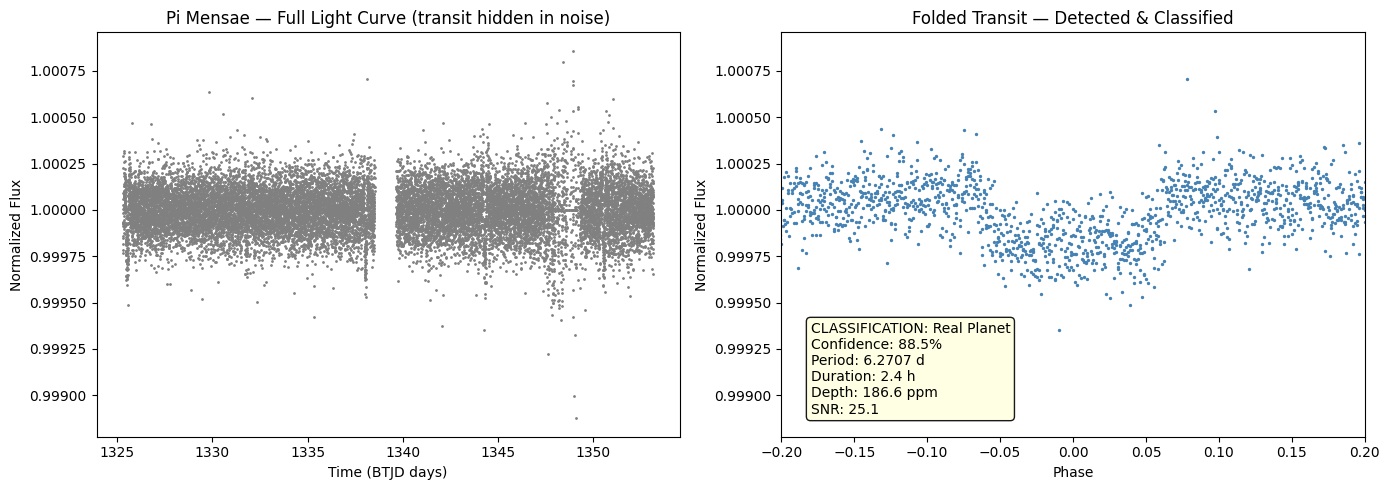

Saved showcase_pi_mensae.png


In [31]:
# import matplotlib.pyplot as plt
# import numpy as np
# import lightkurve as lk

# --- Re-fetch and process Pi Mensae for the figure ---
target = 'Pi Mensae'
lc = lk.search_lightcurve(target, mission='TESS', sector=1,
                          author='SPOC', exptime=120)[0].download()
lc_clean = lc.remove_nans().flatten(window_length=401)

pg = lc_clean.to_periodogram(method='bls', period=np.linspace(1, 15, 5000))
period = pg.period_at_max_power
t0 = pg.transit_time_at_max_power
folded = lc_clean.fold(period=period, epoch_time=t0)

# Run the full pipeline to get classification + confidence
res = full_pipeline(target, sector=1)

# --- Build a 2-panel figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: the raw flattened light curve
ax1.scatter(lc_clean.time.value, lc_clean.flux.value, s=1, color='gray')
ax1.set_xlabel('Time (BTJD days)')
ax1.set_ylabel('Normalized Flux')
ax1.set_title(f'{target} — Full Light Curve (transit hidden in noise)')

# Panel 2: the folded transit with classification annotation
ax2.scatter(folded.time.value, folded.flux.value, s=2, color='steelblue')
ax2.set_xlim(-0.2, 0.2)
ax2.set_xlabel('Phase')
ax2.set_ylabel('Normalized Flux')
ax2.set_title('Folded Transit — Detected & Classified')

# Annotation box with the results
textstr = (f"CLASSIFICATION: {res['classification']}\n"
           f"Confidence: {res['planet_confidence_%']}%\n"
           f"Period: {res['period_d']} d\n"
           f"Duration: {res['duration_h']} h\n"
           f"Depth: {res['depth_ppm']} ppm\n"
           f"SNR: {res['snr']}")
ax2.text(0.05, 0.05, textstr, transform=ax2.transAxes,
         fontsize=10, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('showcase_pi_mensae.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved showcase_pi_mensae.png")